In [11]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cns.data_utils as cdu
import cns

In [13]:
plt.rcParams.update({'font.size': 12, 'figure.figsize': (6, 6), 'figure.dpi': 100})	

In [14]:
data = cdu.main_load(None, use_filter=False, concat=False)[0]
# rename key TCGA_hg19 to TCGA
data["TCGA"] = data["TCGA_hg19"]
del data["TCGA_hg19"]
data["combined"] = cdu.main_load(None, use_filter=False, concat=True)[0]
datasets = list(data.keys())
print(datasets)
colors = {"PCAWG": "C0", "TCGA": "C1", "TRACERx": "C2", "combined": "gray"}

['PCAWG', 'TRACERx', 'TCGA', 'combined']


PCAWG fitered 3
TRACERx fitered 19
TCGA fitered 16
combined fitered 352


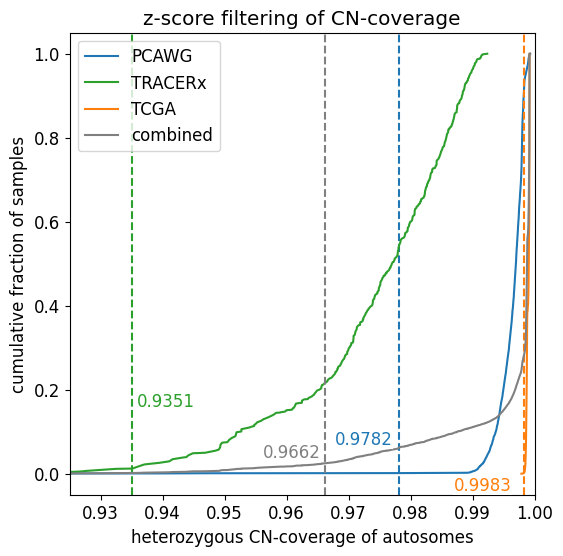

In [15]:
feature = "cover_any_aut"   
min_val = 0.925
outliers = {}
offsets = { "PCAWG": (-0.001, 0.06), "TCGA": (-0.002, -0.05), "TRACERx": (+0.01, 0.15), "combined": (-0.00075, 0.03)}	
for k in datasets:
    selection = data[k][feature]
    X, Y = cns.count_cum_val(selection)
    plt.plot(X, Y, label=k, color=colors[k])   
    # calculate the z-score for selection
    z = (selection - selection.mean()) / selection.std()
    z_filter = z[(z < -3)]
    outliers[k] = data[k].loc[z_filter.index]
    print(k, "fitered", len(outliers[k]))
    x_pos = cns.z_score_filter(selection).min()
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0], 
        offsets[k][1], 
        f"{x_pos:.4f}", 
        color=colors[k], 
        verticalalignment='bottom', 
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', pad=.3)
    )

plt.xlim(min_val, 1)
plt.xlabel("heterozygous CN-coverage of autosomes")
plt.ylabel("cumulative fraction of samples")
plt.legend()
plt.title(f"z-score filtering of CN-coverage")
cdu.save_cns_fig(f"fig_samples_coverage_fraction_zscore")

PCAWG filtered 28
PCAWG below [('SP107557', np.float64(0.5766912308706281))]
TRACERx filtered 89
TCGA filtered 269
combined filtered 1927
combined below [('SP107557', np.float64(0.5766912308706281))]


D:\Ubuntu\CNSistent\cns\utils\anomaly.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  right = (y[-1] - y[i]) / (x[-1] - x[i])


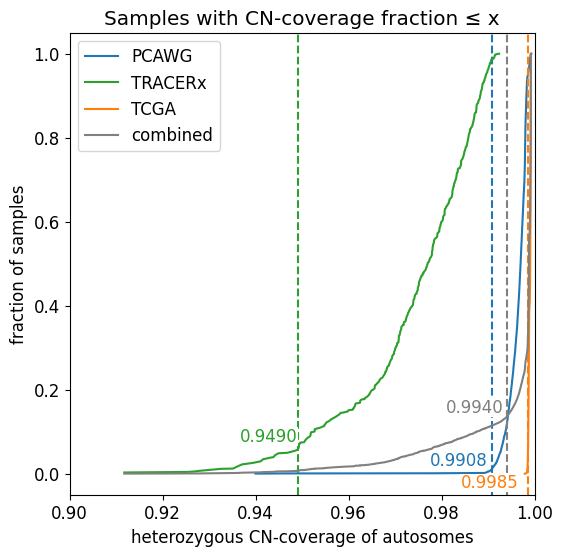

In [16]:
feature = "cover_any_aut"   
min_val = 0.90
offsets = { "PCAWG": (-0.001, 0.000), "TCGA": (-0.002, -0.07), "TRACERx": (+0.0000, 0.01), "combined": (-0.00075, 0.0)}	
for k in datasets:
    X, Y = cns.count_cum_val(data[k][feature], min_val=min_val)
    below = data[k][feature][data[k][feature] < min_val]

    knee_index, knee_value = cns.find_knee(X, Y, knee=False)
    if knee_index < 0:
        continue
    print(k, "filtered", sum(data[k][feature] <= X[knee_index]))
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0], 
        Y[knee_index] + offsets[k][1], 
        f"{x_pos:.4f}", 
        color=colors[k], 
        verticalalignment='bottom', 
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='none', pad=.3)
    )

    if (len(below) > 0):
        print(k, "below", list(zip(below.index.values, below.values)))
    plt.plot(X, Y, label=k, color=colors[k])    

plt.xlim(min_val, 1)
plt.xlabel("heterozygous CN-coverage of autosomes")
plt.ylabel("fraction of samples")
plt.legend()
plt.title(f"Samples with CN-coverage fraction ≤ x")
cdu.save_cns_fig(f"fig_samples_coverage_fraction_knee")

PCAWG filtered at 0.08168795973674023 211 out of 282 ~ 0.1091753774680604
TCGA filtered at 0.07471667836726507 745 out of 1018 ~ 0.10209607862802127
combined filtered at 0.06808240440242698 965 out of 1300 ~ 0.0917172287286581


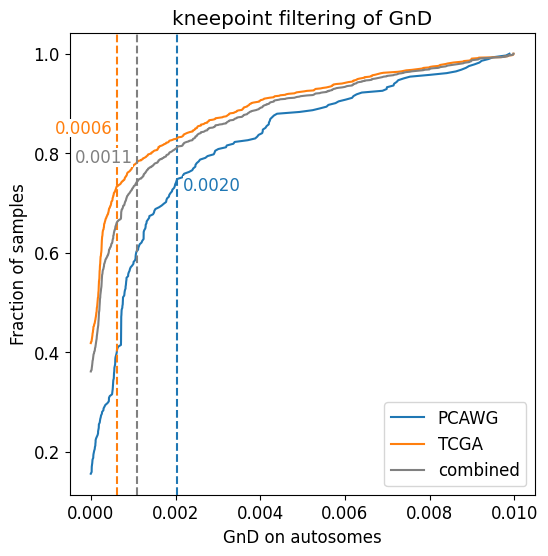

In [17]:
feature = "ane_any_aut"
offsets = {"PCAWG": (0.0015, -0.03), "TCGA": (-0.0001, 0.1), "TRACERx": (+0.0000, 0.01), "combined": (-0.0001, 0.03)}
for k in datasets:
    X, Y = cns.count_cum_val(data[k][feature], max_val=0.01)
    knee_index, knee_value = cns.find_knee(X, Y, knee=True)
    if knee_index < 0:
        continue
    plt.plot(X, Y, label=k, color=colors[k])
    filtered = sum(data[k][feature] <= X[knee_index])
    out_of = sum(data[k][feature] <= 0.01)
    total_sam = len(data[k][feature])
    print(k, "filtered", "at", filtered / len(data[k]), filtered, "out of", out_of, "~", out_of / len(data[k]))
    x_pos = X[knee_index]
    plt.axvline(x_pos, color=colors[k], linestyle="--")
    plt.text(
        x_pos + offsets[k][0],
        Y[knee_index] + offsets[k][1],
        f"{x_pos:.4f}",
        color=colors[k],
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(facecolor="white", edgecolor="none", pad=0.3),
    )

plt.xlabel("GnD on autosomes")
plt.ylabel("Fraction of samples")
plt.title(f"kneepoint filtering of GnD")
plt.legend()
cdu.save_cns_fig(fig_name=f"fig_samples_imbalance_fraction")

In [18]:
data[k].columns

Index(['sex', 'type', 'histology_tier2', 'TCGA_id', 'TCGA_type', 'age',
       'chrom_count', 'chrom_missing', 'cover_any_aut', 'cover_any_sex',
       'cover_any_all', 'cover_both_aut', 'cover_both_sex', 'cover_both_all',
       'loh_both_aut', 'loh_both_sex', 'loh_both_all', 'loh_any_aut',
       'loh_any_sex', 'loh_any_all', 'ane_any_aut', 'ane_any_sex',
       'ane_any_all', 'ane_both_aut', 'ane_both_sex', 'ane_both_all',
       'imb_major_cn_aut', 'imb_major_cn_sex', 'imb_major_cn_all',
       'imb_minor_cn_aut', 'imb_minor_cn_sex', 'imb_minor_cn_all',
       'ploidy_major_cn', 'ploidy_minor_cn', 'ploidy_total_cn',
       'breaks_major_cn_aut', 'breaks_major_cn_sex', 'breaks_major_cn_all',
       'step_major_cn_aut', 'step_major_cn_sex', 'step_major_cn_all',
       'breaks_minor_cn_aut', 'breaks_minor_cn_sex', 'breaks_minor_cn_all',
       'step_minor_cn_aut', 'step_minor_cn_sex', 'step_minor_cn_all',
       'breaks_total_cn_aut', 'breaks_total_cn_sex', 'breaks_total_cn_all',
    

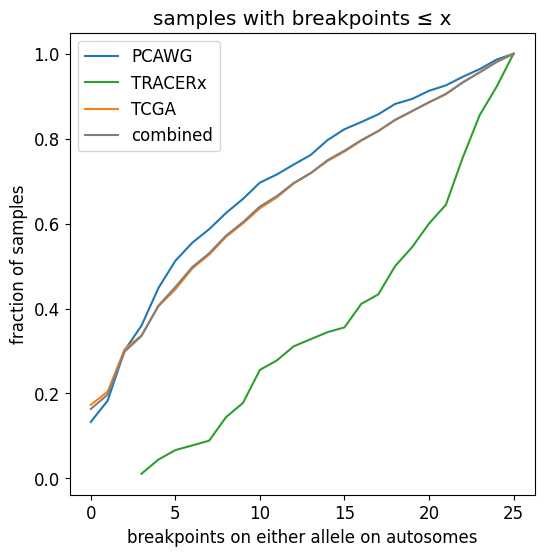

In [19]:
feature = "breaks_total_cn_aut"   
for k in datasets:
    X, Y = cns.count_cum_val(data[k][feature], max_val=25)
    plt.plot(X, Y, label=k, color=colors[k])    

plt.ylabel("fraction of samples")
plt.xlabel("breakpoints on either allele on autosomes")
plt.title(f"samples with breakpoints ≤ x")
plt.legend()
cdu.save_cns_fig(f"fig_samples_breakpoints")

# Full plots

In [20]:
def plot_feature(feature, label, data, min_val=None, max_val=None):
    min_val = np.min([np.min(v[feature]) for v in data.values()]) if min_val is None else min_val
    max_val = np.max([np.max(v[feature]) for v in data.values()]) if max_val is None else max_val
    for k, v in data.items():
        X, Y = cns.count_cum_val(v[feature], min_val, max_val)    
        plt.plot(X, Y, label=k, color=colors[k])    
        
    plt.xlabel(f"{label}")
    plt.ylabel("fraction of samples")
    plt.legend()
    plt.title(f"samples with {label} ≤ x")    

In [21]:
data["combined"].columns

Index(['sex', 'type', 'histology_tier2', 'TCGA_id', 'TCGA_type', 'age',
       'chrom_count', 'chrom_missing', 'cover_any_aut', 'cover_any_sex',
       'cover_any_all', 'cover_both_aut', 'cover_both_sex', 'cover_both_all',
       'loh_both_aut', 'loh_both_sex', 'loh_both_all', 'loh_any_aut',
       'loh_any_sex', 'loh_any_all', 'ane_any_aut', 'ane_any_sex',
       'ane_any_all', 'ane_both_aut', 'ane_both_sex', 'ane_both_all',
       'imb_major_cn_aut', 'imb_major_cn_sex', 'imb_major_cn_all',
       'imb_minor_cn_aut', 'imb_minor_cn_sex', 'imb_minor_cn_all',
       'ploidy_major_cn', 'ploidy_minor_cn', 'ploidy_total_cn',
       'breaks_major_cn_aut', 'breaks_major_cn_sex', 'breaks_major_cn_all',
       'step_major_cn_aut', 'step_major_cn_sex', 'step_major_cn_all',
       'breaks_minor_cn_aut', 'breaks_minor_cn_sex', 'breaks_minor_cn_all',
       'step_minor_cn_aut', 'step_minor_cn_sex', 'step_minor_cn_all',
       'breaks_total_cn_aut', 'breaks_total_cn_sex', 'breaks_total_cn_all',
    

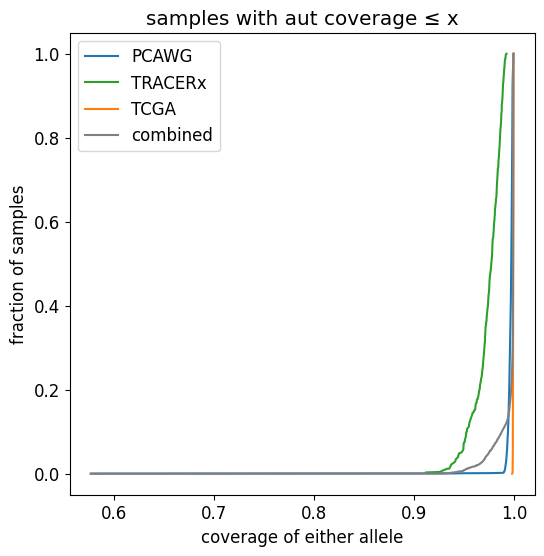

In [22]:
feature = "cover_any_aut"
plot_feature(feature, "aut coverage", data)
plt.xlabel("coverage of either allele")
cdu.save_cns_fig(f"fig_samples_{feature}")

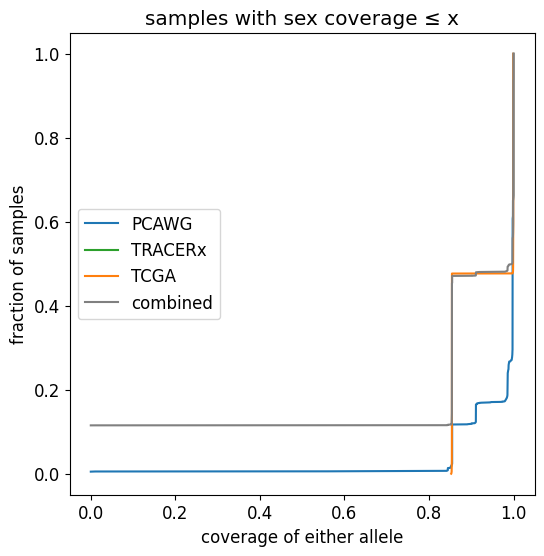

In [23]:
feature = "cover_any_sex"
plot_feature(feature, "sex coverage", data)
plt.xlabel("coverage of either allele")
cdu.save_cns_fig(f"fig_samples_{feature}")

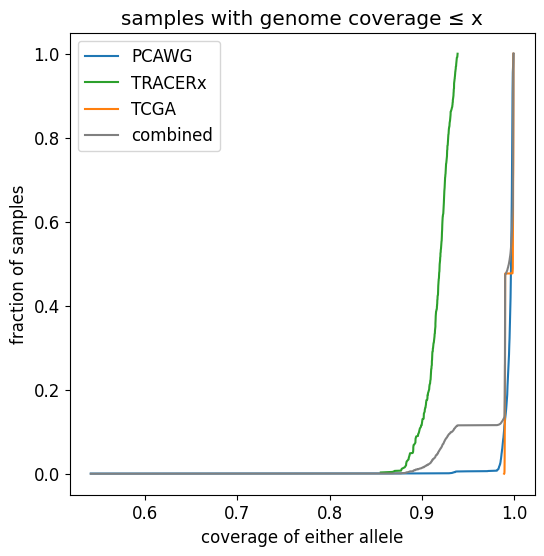

In [24]:
feature = "cover_any_all"
plot_feature(feature, "genome coverage", data)
plt.xlabel("coverage of either allele")
cdu.save_cns_fig(f"fig_samples_{feature}")

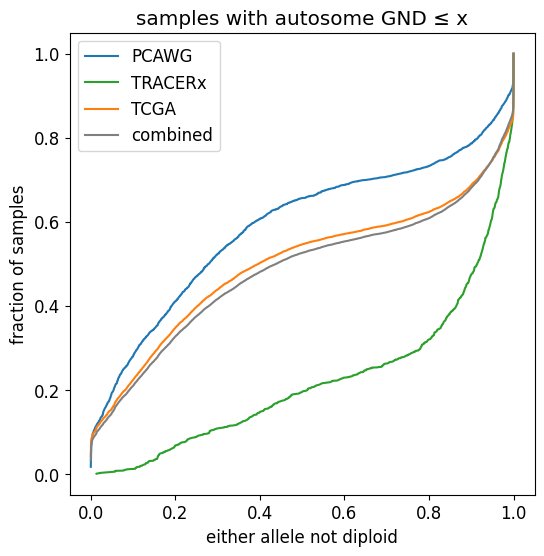

In [25]:
feature = "ane_any_aut"
plot_feature(feature, "autosome GND", data)
plt.xlabel("either allele not diploid")
cdu.save_cns_fig(f"fig_samples_{feature}")

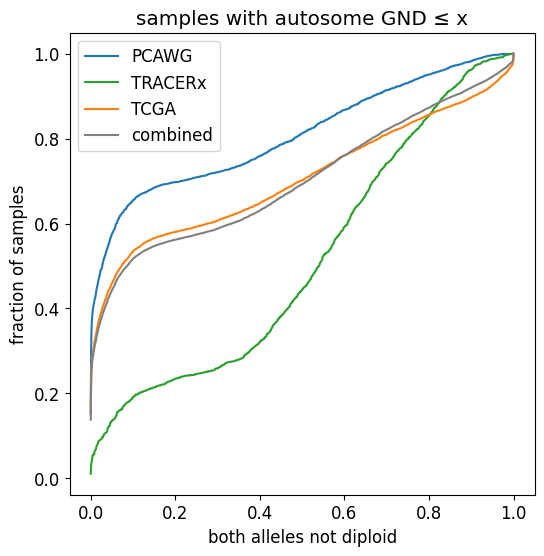

In [26]:
feature = "ane_both_aut"
plot_feature(feature, "autosome GND", data)
plt.xlabel("both alleles not diploid")
cdu.save_cns_fig(f"fig_samples_{feature}")

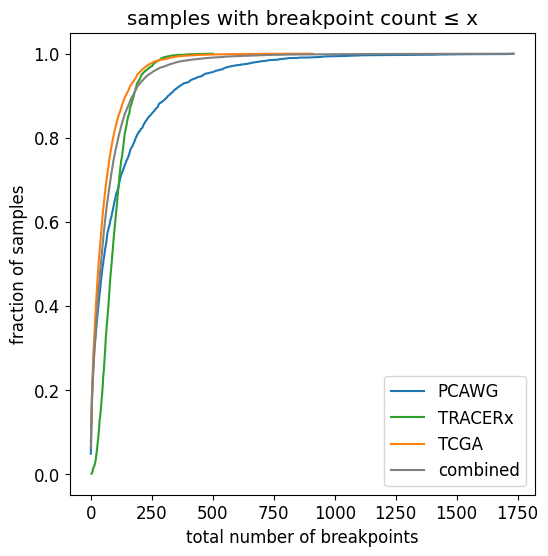

In [27]:
feature = "breaks_total_cn_aut"
plot_feature(feature, "breakpoint count", data)
plt.xlabel("total number of breakpoints")
cdu.save_cns_fig(f"fig_samples_{feature}")

In [28]:
breaks_total_cn_aut = data["combined"]["breaks_total_cn_aut"]

# Calculate the percentiles
percentiles = [50, 75, 90, 99]
percentile_values = np.percentile(breaks_total_cn_aut, percentiles)

# Print the results
for perc, value in zip(percentiles, percentile_values):
    print(f"{perc}th percentile: {value}")

50th percentile: 42.0
75th percentile: 95.0
90th percentile: 173.0
99th percentile: 482.8100000000013


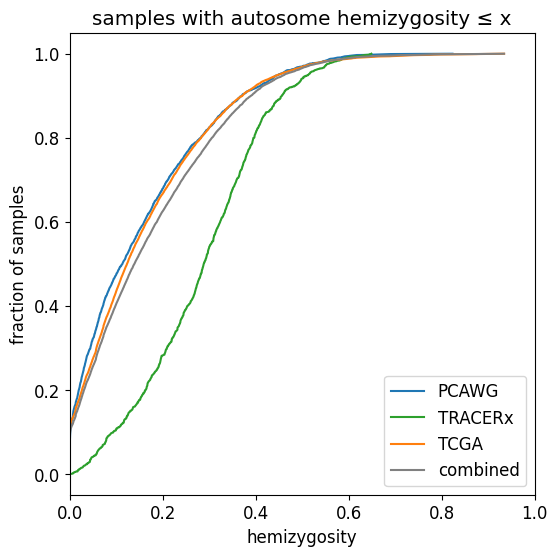

In [29]:
feature = "loh_any_aut"
plot_feature(feature, "autosome hemizygosity", data)
plt.xlim(0,1)
plt.xlabel("hemizygosity")
cdu.save_cns_fig(f"fig_samples_{feature}")

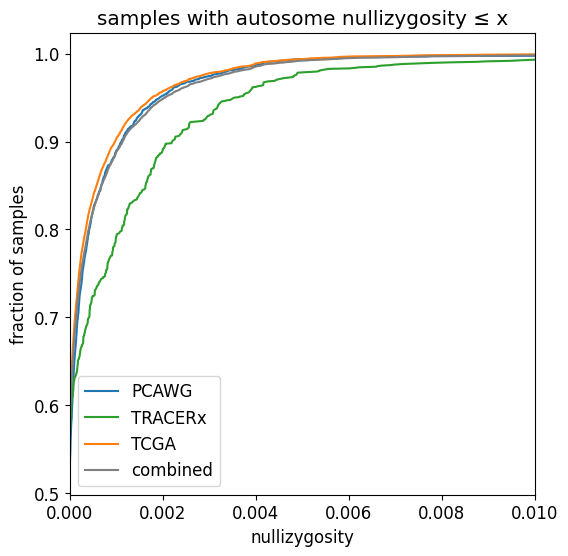

In [30]:
feature = "loh_both_aut"
plot_feature(feature, "autosome nullizygosity", data)
plt.xlim(0,0.01)
plt.xlabel("nullizygosity")
cdu.save_cns_fig(f"fig_samples_{feature}")

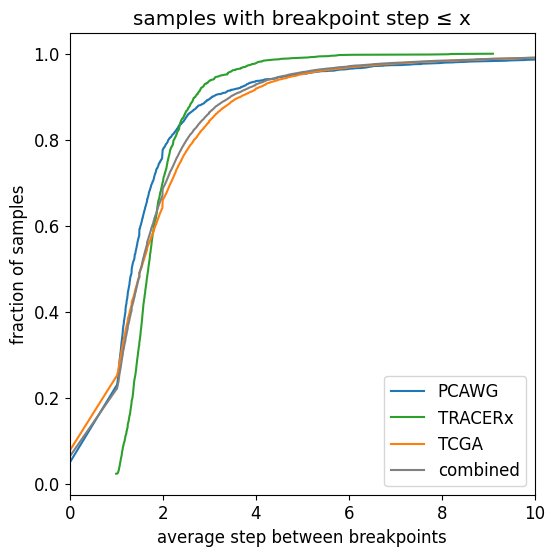

In [31]:
feature = "step_total_cn_aut"
plot_feature(feature, "breakpoint step", data)
plt.xlim(0, 10)
plt.xlabel("average step between breakpoints")
cdu.save_cns_fig(f"fig_samples_{feature}")


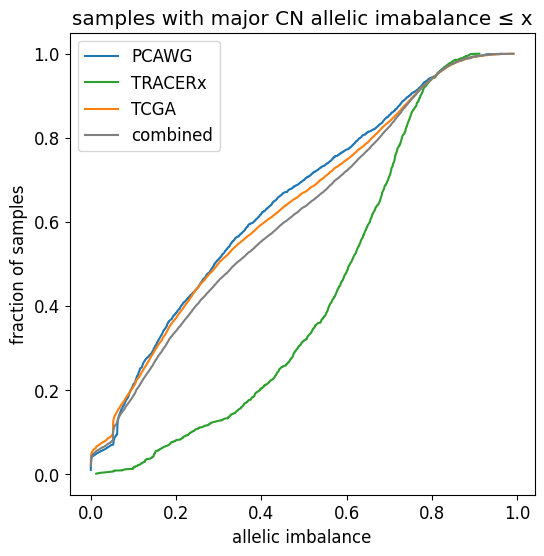

In [32]:
feature = "imb_major_cn_all"
plot_feature(feature, "major CN allelic imabalance", data)
plt.xlabel("allelic imbalance")
cdu.save_cns_fig(f"fig_samples_{feature}")